# RSA design checks

Everything `run_rsa_roi.py` assumes about the stimulus set, checked from `bbt.csv` alone —
no fMRI data. Every gate is an `assert`, so running all cells *is* the check. Rerun when
the BBT is regenerated.

Background on why RSA rather than classification: `run_rsa_roi.py` docstring.

| § | Question | If it fails |
|---|---|---|
| 1 | One value/frequency/category per stimulus? | Model RDMs undefined |
| 2 | Does image → value rotate across subjects? | A "value effect" is just fixed image similarity |
| 3 | Which category holds the extreme values? | Decides whether all 8 stimuli are usable |
| 4 | How correlated are the model RDMs? | Decides whether value separates from category/frequency |
| 5 | What does the targeted contrast compare? | Decides if it's conservative or inflated |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BBT = "/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bbt.csv"
FIGURE_CAT = "figure"
COLS = ["sub_id", "first_stim_name", "first_stim_cat", "first_stim_value", "first_stim_frequ"]

bbt = pd.read_csv(BBT, usecols=COLS)
print(f"{bbt.sub_id.nunique()} subjects, {len(bbt):,} first-stimulus trials")
bbt.head()

62 subjects, 20,336 first-stimulus trials


,sub_id,first_stim_name,first_stim_cat,first_stim_value,first_stim_frequ
0,sub-01,face_male,face,4,1
1,sub-01,hand_back,hand,3,-1
2,sub-01,figure_triangle,figure,1,0
3,sub-01,figure_circle,figure,5,0
4,sub-01,hand_back,hand,3,-1


## 1. Is an 8-condition model RDM well defined?

Each (subject × stimulus) cell must have exactly one value, frequency and category —
otherwise "the value of stimulus A" is undefined. This is also the fact that killed the
classification framing: value is fully determined by identity.

In [2]:
counts = bbt.groupby(["sub_id", "first_stim_name"]).agg(
    n_cat=("first_stim_cat", "nunique"),
    n_val=("first_stim_value", "nunique"),
    n_frq=("first_stim_frequ", "nunique"))
bad = counts[(counts > 1).any(axis=1)]

print(f"cells with >1 value/frequency/category : {len(bad)} of {len(counts)}")
assert len(bad) == 0, f"stimuli without a unique value/frequency/category:\n{bad}"

# The per-(subject, stimulus) table every later section is built from.
tab = bbt.groupby(["sub_id", "first_stim_name"]).agg(
    cat=("first_stim_cat", "first"),
    val=("first_stim_value", "first"),
    frq=("first_stim_frequ", "first")).reset_index()

n_stim = tab.groupby("sub_id").size()
print(f"stimuli per subject                    : {sorted(n_stim.unique())}")
assert (n_stim == 8).all(), f"not every subject has 8 stimuli:\n{n_stim[n_stim != 8]}"

print(f"reward levels present                  : {sorted(tab.val.unique())}")
print(f"frequency levels present               : {sorted(tab.frq.unique())}")
print(f"categories                             : {sorted(tab.cat.unique())}")
print("\nvalue x frequency layout (stimulus count, pooled over subjects):")
print(pd.crosstab(tab.val, tab.frq).to_string())

cells with >1 value/frequency/category : 0 of 496
stimuli per subject                    : [np.int64(8)]
reward levels present                  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
frequency levels present               : [np.int64(-1), np.int64(0), np.int64(1)]
categories                             : ['face', 'figure', 'hand', 'house']

value x frequency layout (stimulus count, pooled over subjects):
frq  -1   0   1
val            
1     0  62   0
2    62   0  62
3    62   0  62
4    62   0  62
5     0  62   0


## 2. Counterbalancing — why RSA is answerable where classification wasn't

If every subject saw `face_female` at value 2, a group value effect would be
indistinguishable from an idiosyncratic visual similarity between whichever images shared
a value. So: does the image → value assignment rotate? `n == 1` would sink the whole
approach.

distinct image -> value assignments : 12  (across 62 subjects)

the distinct assignments, and how many subjects use each:


first_stim_name,face_female,face_male,figure_circle,figure_triangle,hand_back,hand_palm,house_1,house_2,n_subjects
sub_id,,,,,,,,,
sub-01,2,4,5,1,3,4,3,2,4
sub-02,3,2,1,5,4,2,4,3,9
sub-03,4,2,5,1,3,2,3,4,8
sub-04,3,2,5,1,4,2,4,3,2
sub-06,3,4,1,5,2,4,2,3,3
sub-07,2,3,1,5,4,3,4,2,6
sub-09,4,2,1,5,3,2,3,4,6
sub-10,2,3,5,1,4,3,4,2,5
sub-12,2,4,1,5,3,4,3,2,7


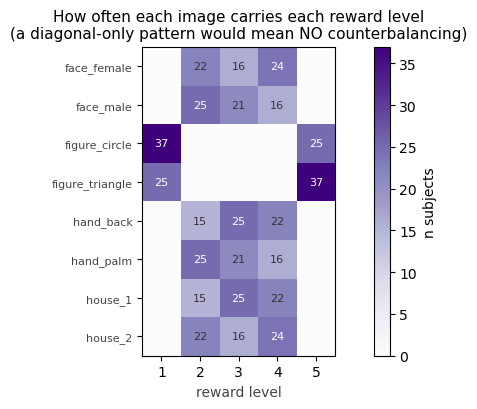

In [3]:
val_map = tab.pivot(index="sub_id", columns="first_stim_name", values="val")
assignments = val_map.drop_duplicates()

print(f"distinct image -> value assignments : {len(assignments)}  "
      f"(across {len(val_map)} subjects)")
assert len(assignments) > 1, (
    "image->value mapping is FIXED across subjects — a group-level value effect would be "
    "indistinguishable from a fixed visual similarity. RSA cannot answer the question.")

print("\nthe distinct assignments, and how many subjects use each:")
key = val_map.astype(int).astype(str).agg("-".join, axis=1)
tally = key.value_counts()
display(assignments.assign(n_subjects=[tally[key[s]] for s in assignments.index]))

# Per-image spread: does each image visit several values across the sample?
fig, ax = plt.subplots(figsize=(8.5, 4.2))
images = sorted(tab.first_stim_name.unique())
levels = sorted(tab.val.unique())
mat = np.array([[int(((tab.first_stim_name == im) & (tab.val == v)).sum())
                 for v in levels] for im in images])
im_ = ax.imshow(mat, cmap="Purples", vmin=0)          # counts -> sequential, single hue
ax.set_xticks(range(len(levels))); ax.set_xticklabels(levels)
ax.set_yticks(range(len(images))); ax.set_yticklabels(images, fontsize=8, color="#444444")
ax.set_xlabel("reward level", color="#444444")
ax.set_title("How often each image carries each reward level\n"
             "(a diagonal-only pattern would mean NO counterbalancing)", fontsize=11)
for i in range(len(images)):
    for j in range(len(levels)):
        if mat[i, j]:
            ax.text(j, i, mat[i, j], ha="center", va="center", fontsize=8,
                    color="#FFFFFF" if mat[i, j] > mat.max() * .6 else "#333333")
fig.colorbar(im_, ax=ax, fraction=0.035, label="n subjects")
fig.tight_layout()
plt.show()

## 3. …but it doesn't rotate freely

Is any category locked to particular reward levels? If so, "value" and "that category" are
the same regressor at the group level, and adding subjects never separates them.

how many subject-stimuli each category contributes at each reward level:
val      1   2   3   4   5
cat                       
face     0  47  37  40   0
figure  62   0   0   0  62
hand     0  40  46  38   0
house    0  37  41  46   0

category holding values {1, 5}:
cat
figure    62

>>> 'figure' carries the extreme values for ALL 62 subjects.
>>> 'extreme value' and 'figure vs rest' are the SAME contrast at the group level.
>>> Consequence: the primary analysis must drop that category (the non-figure subset).


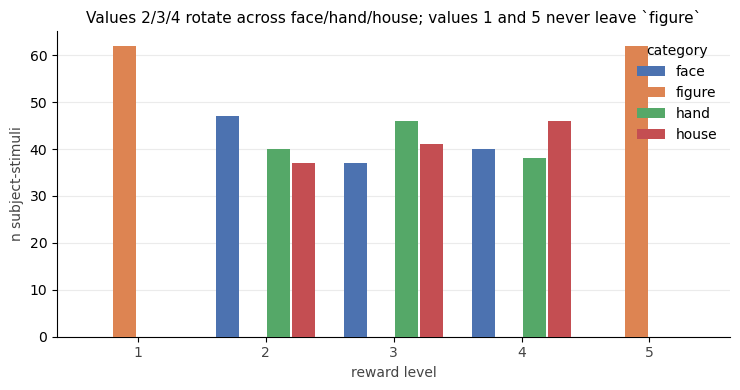

In [4]:
cats = sorted(tab.cat.unique())
ct = pd.crosstab(tab.cat, tab.val).reindex(cats)
print("how many subject-stimuli each category contributes at each reward level:")
print(ct.to_string())

extremes = tab[tab.val.isin([1, 5])].groupby("sub_id")["cat"].apply(
    lambda s: "/".join(sorted(set(s))))
print(f"\ncategory holding values {{1, 5}}:")
print(extremes.value_counts().to_string())

locked = extremes.value_counts()
if locked.iloc[0] == len(extremes):
    print(f"\n>>> '{locked.index[0]}' carries the extreme values for ALL {len(extremes)} "
          f"subjects.\n>>> 'extreme value' and '{locked.index[0]} vs rest' are the SAME "
          f"contrast at the group level.\n>>> Consequence: the primary analysis must drop "
          f"that category (the non-figure subset).")

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(levels)); w = .2
cat_colors = {"face": "#4C72B0", "figure": "#DD8452", "hand": "#55A868", "house": "#C44E52"}
for j, c in enumerate(cats):
    ax.bar(x + (j - (len(cats) - 1) / 2) * w, ct.loc[c, levels].values, width=w - .02,
           color=cat_colors.get(c, "#937860"), label=c, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(levels, color="#444444")
ax.set_xlabel("reward level", color="#444444")
ax.set_ylabel("n subject-stimuli", color="#444444")
ax.set_title("Values 2/3/4 rotate across face/hand/house; values 1 and 5 never leave `figure`",
             fontsize=11)
ax.legend(frameon=False, title="category")
ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Can the regression tell the three models apart?

Watch whether each correlation **varies across subjects**. One that's identical for
everyone is fixed by design — more subjects won't help, only dropping stimuli will. One
that varies is identified at the group level.


--- all 8 stimuli: 8 stimuli, 28 pairs ---
  category  ~ value     -0.179 .. -0.179   FIXED by design
  category  ~ frequency -0.232 .. +0.310   varies across subjects
  value     ~ frequency -0.346 .. -0.346   FIXED by design

--- non-figure subset: 6 stimuli, 15 pairs ---
  category  ~ value     -0.196 .. -0.196   FIXED by design
  category  ~ frequency -0.408 .. +0.272   varies across subjects
  value     ~ frequency -0.320 .. -0.320   FIXED by design


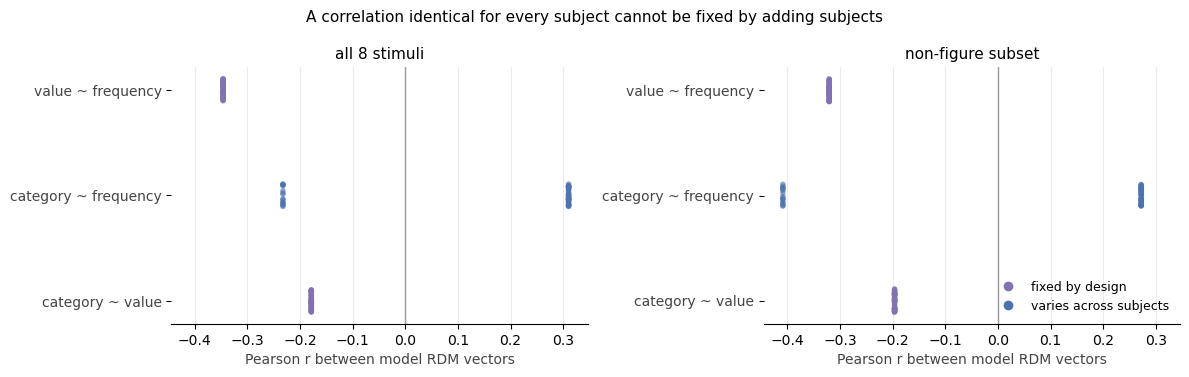

In [5]:
def model_vectors(sub_tab, drop_figure=False):
    """Upper-triangle vectors of the category / value / frequency model RDMs.

    Mirrors run_rsa_roi.py: category is 0-same / 1-different, value and frequency are
    absolute differences. Stimuli sorted by name, as in the saved RDMs.
    """
    d = sub_tab.sort_values("first_stim_name")
    if drop_figure:
        d = d[d.cat != FIGURE_CAT]
    iu = np.triu_indices(len(d), 1)
    return d, {
        "category":  (d.cat.values[:, None] != d.cat.values[None, :]).astype(float)[iu],
        "value":     np.abs(d.val.values[:, None] - d.val.values[None, :]).astype(float)[iu],
        "frequency": np.abs(d.frq.values[:, None] - d.frq.values[None, :]).astype(float)[iu],
    }


PAIRS = [("category", "value"), ("category", "frequency"), ("value", "frequency")]
subs = sorted(tab.sub_id.unique())
inter = {}

for label, drop in [("all 8 stimuli", False), ("non-figure subset", True)]:
    rows = []
    for s in subs:
        d, mv = model_vectors(tab[tab.sub_id == s], drop_figure=drop)
        rows.append({f"{a}~{b}": np.corrcoef(mv[a], mv[b])[0, 1] for a, b in PAIRS}
                    | {"n_stim": len(d), "n_pairs": len(mv["value"])})
    inter[label] = pd.DataFrame(rows, index=subs)
    r = inter[label]
    print(f"\n--- {label}: {r.n_stim.iloc[0]} stimuli, {r.n_pairs.iloc[0]} pairs ---")
    for a, b in PAIRS:
        col = r[f"{a}~{b}"]
        fixed = np.isclose(col.min(), col.max())
        print(f"  {a:9s} ~ {b:9s} {col.min():+.3f} .. {col.max():+.3f}"
              f"   {'FIXED by design' if fixed else 'varies across subjects'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, (label, r) in zip(axes, inter.items()):
    for i, (a, b) in enumerate(PAIRS):
        col = r[f"{a}~{b}"]
        fixed = np.isclose(col.min(), col.max())
        ax.scatter(col, np.full(len(col), i) + np.random.uniform(-.11, .11, len(col)),
                   s=16, color="#8172B3" if fixed else "#4C72B0",
                   alpha=.6, edgecolor="none", zorder=3)
    ax.axvline(0, color="#999999", linewidth=1, zorder=1)
    ax.set_yticks(range(len(PAIRS)))
    ax.set_yticklabels([f"{a} ~ {b}" for a, b in PAIRS], color="#444444")
    ax.set_xlabel("Pearson r between model RDM vectors", color="#444444")
    ax.set_title(label, fontsize=11)
    ax.grid(axis="x", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right", "left"):
        ax.spines[s_].set_visible(False)
handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, label=l)
           for c, l in [("#8172B3", "fixed by design"), ("#4C72B0", "varies across subjects")]]
axes[1].legend(handles=handles, frameon=False, loc="lower right", fontsize=9)
fig.suptitle("A correlation identical for every subject cannot be fixed by adding subjects",
             fontsize=11)
fig.tight_layout()
plt.show()

## 5. What the targeted contrast actually compares

Among pairs that are all different-identity and all different-category: do those sharing a
reward level differ from those that don't? Two things to establish — how many cells carry
it, and whether frequency is balanced across the two groups (which decides if the contrast
is conservative or inflated).


--- all 8 stimuli ---
  same-value cross-category cells : [np.int64(3)]
  diff-value cross-category cells : [np.int64(21)]
  every same-value pair is cross-category : True
  mean |dfreq|, same-value pairs  : 2.000
  mean |dfreq|, diff-value pairs  : 0.998
  >>> same-value pairs are the MOST frequency-different pairs.
  >>> If frequency is represented it pushes this contrast NEGATIVE,
  >>> i.e. against the value hypothesis. The contrast is CONSERVATIVE.

--- non-figure subset ---
  same-value cross-category cells : [np.int64(3)]
  diff-value cross-category cells : [np.int64(9)]
  every same-value pair is cross-category : True
  mean |dfreq|, same-value pairs  : 2.000
  mean |dfreq|, diff-value pairs  : 0.996
  >>> same-value pairs are the MOST frequency-different pairs.
  >>> If frequency is represented it pushes this contrast NEGATIVE,
  >>> i.e. against the value hypothesis. The contrast is CONSERVATIVE.


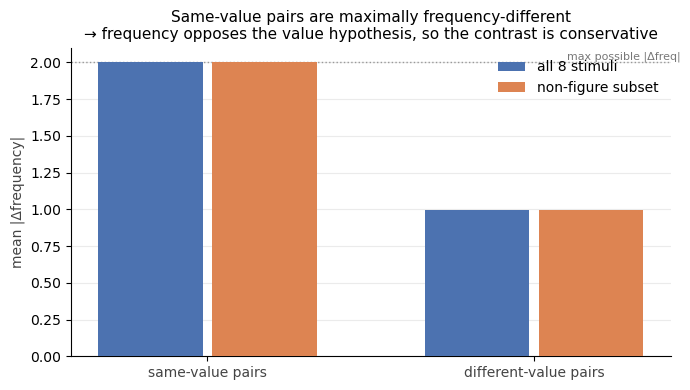

In [6]:
rows = []
for label, drop in [("all 8 stimuli", False), ("non-figure subset", True)]:
    for s in subs:
        _, mv = model_vectors(tab[tab.sub_id == s], drop_figure=drop)
        cross = mv["category"] > 0
        same_v = mv["value"] == 0
        rows.append(dict(
            subset=label, sub_id=s,
            n_same=int((cross & same_v).sum()), n_diff=int((cross & ~same_v).sum()),
            all_same_are_cross=bool(cross[same_v].all()),
            dfrq_same=mv["frequency"][cross & same_v].mean(),
            dfrq_diff=mv["frequency"][cross & ~same_v].mean()))
con = pd.DataFrame(rows)

for label, g in con.groupby("subset", sort=False):
    print(f"\n--- {label} ---")
    print(f"  same-value cross-category cells : {sorted(g.n_same.unique())}")
    print(f"  diff-value cross-category cells : {sorted(g.n_diff.unique())}")
    print(f"  every same-value pair is cross-category : {g.all_same_are_cross.all()}")
    print(f"  mean |dfreq|, same-value pairs  : {g.dfrq_same.mean():.3f}")
    print(f"  mean |dfreq|, diff-value pairs  : {g.dfrq_diff.mean():.3f}")
    if g.dfrq_same.mean() > g.dfrq_diff.mean():
        print("  >>> same-value pairs are the MOST frequency-different pairs.")
        print("  >>> If frequency is represented it pushes this contrast NEGATIVE,")
        print("  >>> i.e. against the value hypothesis. The contrast is CONSERVATIVE.")
    else:
        print("  >>> WARNING: frequency favours the value hypothesis here — contrast inflated.")

assert con.groupby("subset").all_same_are_cross.all().all(), \
    "some same-value pairs are within-category — the contrast is no longer identity-clean"

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2); w = .35
for j, (label, g) in enumerate(con.groupby("subset", sort=False)):
    vals = [g.dfrq_same.mean(), g.dfrq_diff.mean()]
    ax.bar(x + (j - .5) * w, vals, width=w - .03,
           color=["#4C72B0", "#DD8452"][j], label=label, zorder=3)
ax.axhline(2, color="#999999", linewidth=1, linestyle=":", zorder=1)
ax.text(1.45, 2.02, "max possible |Δfreq|", fontsize=8, color="#777777", ha="right")
ax.set_xticks(x)
ax.set_xticklabels(["same-value pairs", "different-value pairs"], color="#444444")
ax.set_ylabel("mean |Δfrequency|", color="#444444")
ax.set_title("Same-value pairs are maximally frequency-different\n"
             "→ frequency opposes the value hypothesis, so the contrast is conservative",
             fontsize=11)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
plt.show()

## Summary

n=62, 2026-08-26.

| Check | Result | Consequence |
|---|---|---|
| Uniqueness | 0/496 bad | Model RDMs well defined |
| Counterbalancing | **12** assignments | Group value effect ≠ fixed image similarity |
| Extreme values | `figure` holds {1,5}, **62/62** | **Non-figure subset is primary** |
| corr(cat, value) | −0.179, fixed | Mild; regress out |
| corr(value, freq) | −0.346, fixed | Frequency stays as covariate |
| corr(cat, freq) | −0.232…0.310, varies | Identified at group level |
| Contrast cells | 3 same-value vs 9 diff (non-figure) | Group test only |
| Frequency balance | 2.000 vs 0.996 | Contrast is **conservative** |

**The limit:** counterbalancing rescues values {2,3,4}; the `figure` constraint means the
extremes of the reward range are not identifiable in this design. No analysis choice fixes
that.

Next: [`crossnobis_validation.ipynb`](crossnobis_validation.ipynb) ·
[`rsa_roi_results.ipynb`](rsa_roi_results.ipynb)